In [2]:
import pandas as pd
import os
# Define the folder containing the SQL analytical exports
data_path = r"C:\Users\john-\OneDrive\桌面\eleven\第二版\sql导出csv"
# Load the customer-level analytical dataset exported from SQL
customer_summary = pd.read_csv(
    os.path.join(data_path, "customer_summary.csv"),
    header=None,
    names=[
        "customer_unique_id","customer_segment","first_purchase_date","last_purchase_date",
        "order_count","units_sold","revenue","aov","purchase_frequency",
        "customer_lifetime_days","repeat_customer_flag","revenue_share_pct"
    ]
)
# Convert customer purchase dates to pandas datetime format for time-based analysis
customer_summary["first_purchase_date"] = pd.to_datetime(customer_summary["first_purchase_date"])
customer_summary["last_purchase_date"] = pd.to_datetime(customer_summary["last_purchase_date"])
# Verify the imported customer-level dataset
print(f"Rows: {len(customer_summary):,}")
print(f"Columns: {customer_summary.shape[1]}")
customer_summary.head()

# Calculate total customer revenue as the denominator for revenue-share analysis
total_customer_revenue = customer_summary["revenue"].sum()

Rows: 279,199
Columns: 12


In [3]:
# Analyze customer segments by customer count, revenue, and purchasing behavior
customer_analysis = customer_summary.groupby("customer_segment", as_index=False).agg(
    customers=("customer_unique_id", "count"),
    revenue=("revenue", "sum"),
    orders=("order_count", "sum"),
    units_sold=("units_sold", "sum")
)
# Calculate each segment's share of total customers and revenue
total_customers = customer_summary["customer_unique_id"].nunique()
total_customer_revenue = customer_summary["revenue"].sum()
customer_analysis["customer_share_pct"] = customer_analysis["customers"] / total_customers * 100
customer_analysis["revenue_share_pct"] = customer_analysis["revenue"] / total_customer_revenue * 100
# Calculate average revenue and orders generated per customer in each segment
customer_analysis["revenue_per_customer"] = customer_analysis["revenue"] / customer_analysis["customers"]
customer_analysis["orders_per_customer"] = customer_analysis["orders"] / customer_analysis["customers"]
# Sort segments by revenue contribution for business analysis
customer_analysis = customer_analysis.sort_values("revenue", ascending=False)
customer_analysis

,customer_segment,customers,revenue,orders,units_sold,customer_share_pct,revenue_share_pct,revenue_per_customer,orders_per_customer
0,Consumer,195831,6.267264e+08,700676,1402039,70.140294,63.747480,3200.343100,3.577963
2,VIP,27811,1.782529e+08,99784,398742,9.960996,18.130998,6409.439761,3.587933
1,Corporate,55557,1.781598e+08,199540,399038,19.898710,18.121522,3206.792299,3.591627


In [4]:
# Analyze repeat versus one-time customers and their contribution to revenue
repeat_analysis = customer_summary.groupby("repeat_customer_flag", as_index=False).agg(
    customers=("customer_unique_id", "count"),
    revenue=("revenue", "sum"),
    orders=("order_count", "sum"),
    units_sold=("units_sold", "sum")
)
# Replace the binary flag with business-friendly customer labels
repeat_analysis["customer_type"] = repeat_analysis["repeat_customer_flag"].map({
    0: "One-time Customer",
    1: "Repeat Customer"
})
# Calculate customer and revenue shares
repeat_analysis["customer_share_pct"] = repeat_analysis["customers"] / customer_summary["customer_unique_id"].nunique() * 100
repeat_analysis["revenue_share_pct"] = repeat_analysis["revenue"] / customer_summary["revenue"].sum() * 100
# Calculate average revenue and orders per customer
repeat_analysis["revenue_per_customer"] = repeat_analysis["revenue"] / repeat_analysis["customers"]
repeat_analysis["orders_per_customer"] = repeat_analysis["orders"] / repeat_analysis["customers"]
# Sort repeat customers first for easier business interpretation
repeat_analysis = repeat_analysis.sort_values("repeat_customer_flag", ascending=False)
repeat_analysis

,repeat_customer_flag,customers,revenue,orders,units_sold,customer_type,customer_share_pct,revenue_share_pct,revenue_per_customer,orders_per_customer
1,1,234692,9.393406e+08,955493,2101893,Repeat Customer,84.05904,95.545038,4002.439820,4.071264
0,0,44507,4.379847e+07,44507,97926,One-time Customer,15.94096,4.454962,984.080533,1.000000


In [5]:
# Analyze customer revenue concentration using cumulative revenue contribution
customer_concentration = customer_summary[
    ["customer_unique_id", "customer_segment", "revenue"]
].copy()
# Rank customers from highest to lowest revenue contribution
customer_concentration = customer_concentration.sort_values("revenue", ascending=False).reset_index(drop=True)
# Calculate each customer's share and cumulative share of total revenue
total_revenue = customer_concentration["revenue"].sum()
customer_concentration["revenue_share_pct"] = customer_concentration["revenue"] / total_revenue * 100
customer_concentration["cumulative_revenue_pct"] = customer_concentration["revenue_share_pct"].cumsum()
customer_concentration["customer_rank"] = customer_concentration.index + 1
customer_concentration["customer_percentile"] = customer_concentration["customer_rank"] / len(customer_concentration) * 100
# Measure revenue contribution from the top 1%, 5%, 10%, and 20% of customers
concentration_summary = []
for pct in [1, 5, 10, 20]:
    n = int(len(customer_concentration) * pct / 100)
    revenue_share = customer_concentration.loc[:n-1, "revenue"].sum() / total_revenue * 100
    concentration_summary.append({
        "customer_group": f"Top {pct}%",
        "customers": n,
        "revenue_share_pct": revenue_share
    })
concentration_summary = pd.DataFrame(concentration_summary)
concentration_summary

,customer_group,customers,revenue_share_pct
0,Top 1%,2791,4.669950
1,Top 5%,13959,16.806343
2,Top 10%,27919,28.308253
3,Top 20%,55839,46.210939


In [6]:
# Analyze customer lifetime and its relationship with purchasing behavior and revenue
lifetime_analysis = customer_summary.groupby("customer_segment", as_index=False).agg(
    customers=("customer_unique_id", "count"),
    avg_lifetime_days=("customer_lifetime_days", "mean"),
    median_lifetime_days=("customer_lifetime_days", "median"),
    avg_orders=("order_count", "mean"),
    avg_revenue=("revenue", "mean")
)
# Compare customers with different lifecycle lengths
customer_summary["lifetime_group"] = pd.cut(
    customer_summary["customer_lifetime_days"],
    bins=[-1, 90, 365, 730, 1095, float("inf")],
    labels=["0-90 days", "91-365 days", "1-2 years", "2-3 years", "3+ years"]
)
lifetime_groups = customer_summary.groupby("lifetime_group", observed=False).agg(
    customers=("customer_unique_id", "count"),
    avg_orders=("order_count", "mean"),
    avg_revenue=("revenue", "mean"),
    total_revenue=("revenue", "sum")
).reset_index()
# Calculate each lifetime group's share of total customer revenue
lifetime_groups["revenue_share_pct"] = lifetime_groups["total_revenue"] / customer_summary["revenue"].sum() * 100
lifetime_groups

,lifetime_group,customers,avg_orders,avg_revenue,total_revenue,revenue_share_pct
0,0-90 days,50040,1.120544,1107.252554,5.540692e+07,5.635715
1,91-365 days,19907,2.424122,2377.817714,4.733522e+07,4.814702
2,1-2 years,32501,3.046737,3001.406722,9.754872e+07,9.922169
3,2-3 years,36398,3.684049,3616.424169,1.316306e+08,13.388808
4,3+ years,140353,4.720647,4639.855342,6.512176e+08,66.238606


In [8]:
# Analyze monthly customer revenue and customer activity over time
# Load the monthly customer performance dataset for time-series analysis
customer_performance = pd.read_csv(
    os.path.join(data_path, "customer_performance.csv"),
    header=None,
    names=[
        "year","quarter","month","month_name","month_number","month_period",
        "customer_unique_id","customer_segment","revenue","orders","aov","month_start_date"
    ]
)
# Convert the monthly date field to pandas datetime format
customer_performance["month_start_date"] = pd.to_datetime(customer_performance["month_start_date"])
# Verify the imported dataset
print(f"Rows: {len(customer_performance):,}")
print(f"Columns: {customer_performance.shape[1]}")
customer_performance.head()
customer_trend = customer_performance.groupby(
    ["year", "month", "month_start_date"], as_index=False
).agg(
    revenue=("revenue", "sum"),
    customers=("customer_unique_id", "nunique"),
    orders=("orders", "sum")
)
# Calculate average revenue generated per active customer each month
customer_trend["revenue_per_customer"] = customer_trend["revenue"] / customer_trend["customers"]
# Calculate month-over-month changes in revenue and active customers
customer_trend["revenue_mom_pct"] = customer_trend["revenue"].pct_change() * 100
customer_trend["customers_mom_pct"] = customer_trend["customers"].pct_change() * 100
# Sort the monthly customer trend chronologically
customer_trend = customer_trend.sort_values("month_start_date").reset_index(drop=True)
customer_trend.tail()

Rows: 965,060
Columns: 12


,year,month,month_start_date,revenue,customers,orders,revenue_per_customer,revenue_mom_pct,customers_mom_pct
79,2025,8,2025-08-01,19656108.56,26350,27808,745.962374,6.803615,4.671486
80,2025,9,2025-09-01,13755817.30,15472,15990,889.078161,-30.017596,-41.282732
81,2025,10,2025-10-01,13950091.11,15733,16222,886.677119,1.412303,1.686918
82,2025,11,2025-11-01,63939806.14,41654,45299,1535.021994,358.346871,164.755609
83,2025,12,2025-12-01,60690851.53,39459,42683,1538.073736,-5.081271,-5.269602


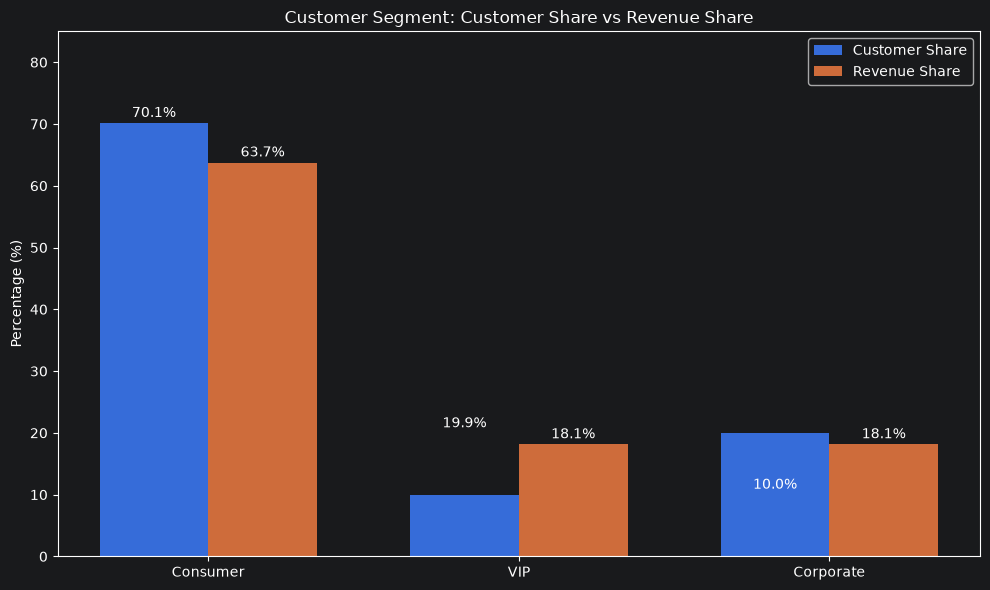

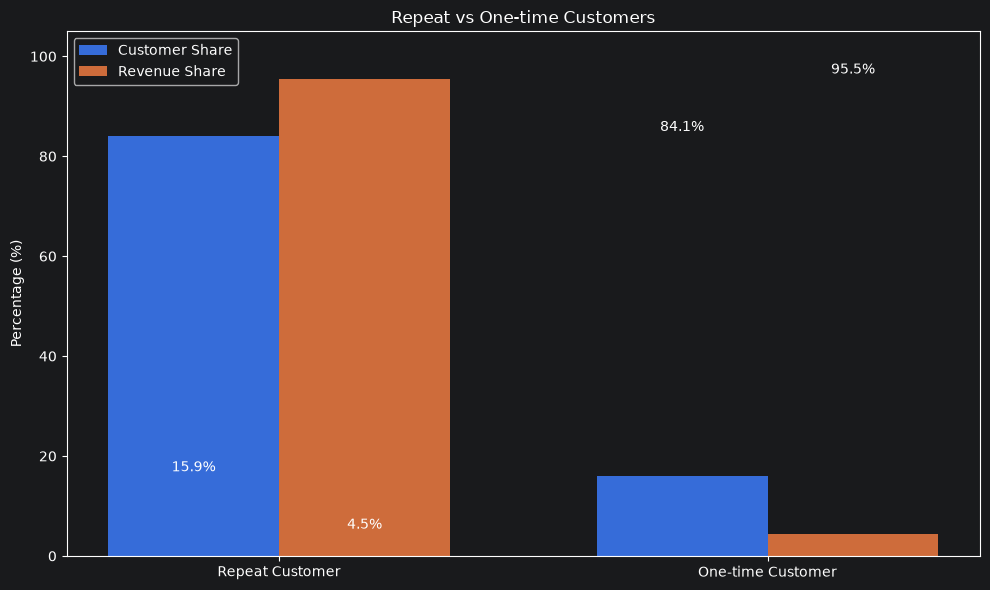

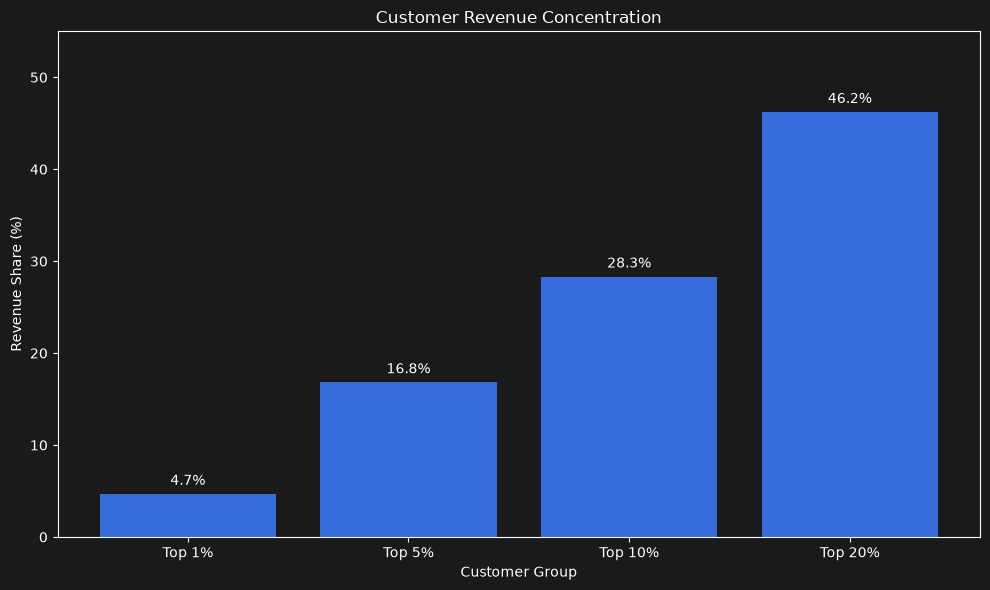

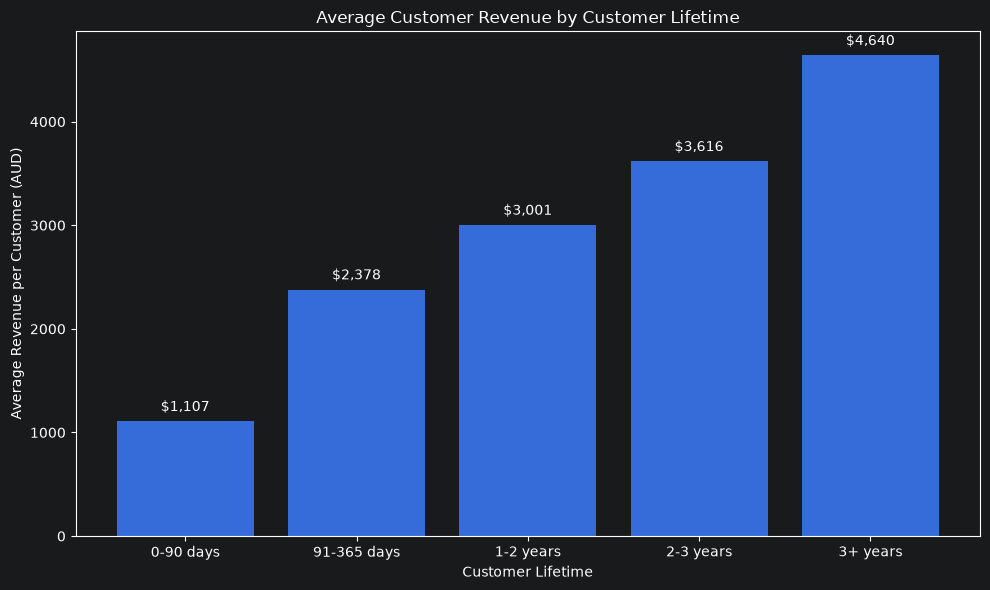

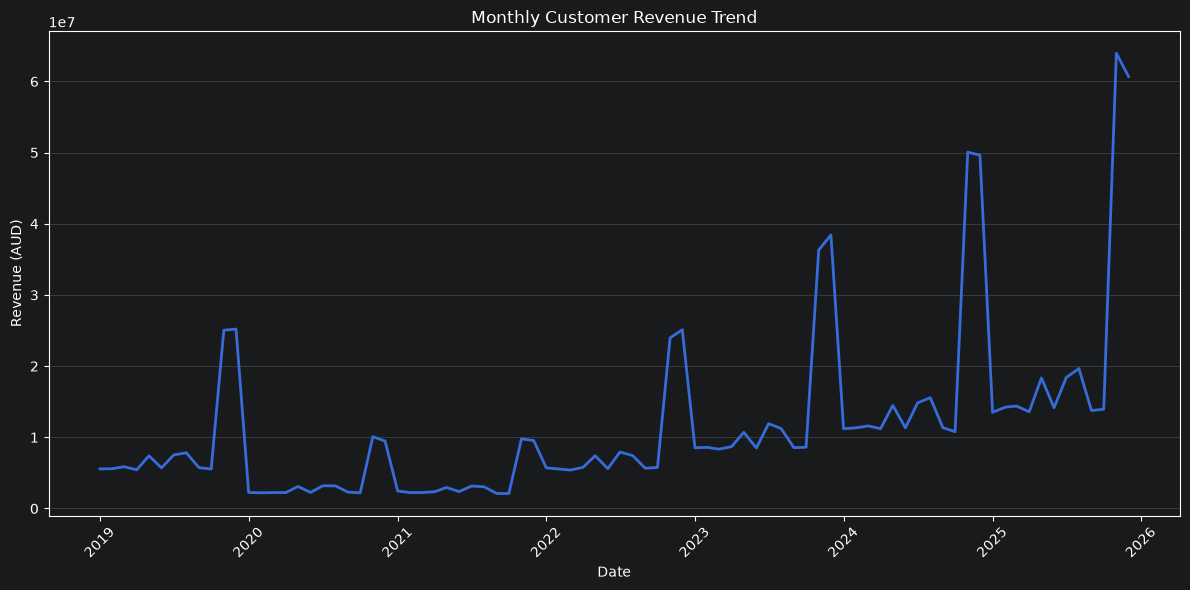

In [11]:
import matplotlib.pyplot as plt
import numpy as np
# Set a consistent figure size for portfolio-ready visualizations
FIGSIZE = (10, 6)
# ============================================================
# 1. Customer Segment: Customer Share vs Revenue Share
# ============================================================
segment_chart = customer_analysis[
    ["customer_segment", "customer_share_pct", "revenue_share_pct"]
].copy()
x = np.arange(len(segment_chart))
width = 0.35
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.bar(x - width / 2, segment_chart["customer_share_pct"], width, label="Customer Share")
ax.bar(x + width / 2, segment_chart["revenue_share_pct"], width, label="Revenue Share")
for i, row in segment_chart.iterrows():
    ax.text(i - width / 2, row["customer_share_pct"] + 1, f'{row["customer_share_pct"]:.1f}%', ha="center")
    ax.text(i + width / 2, row["revenue_share_pct"] + 1, f'{row["revenue_share_pct"]:.1f}%', ha="center")
ax.set_title("Customer Segment: Customer Share vs Revenue Share")
ax.set_ylabel("Percentage (%)")
ax.set_xticks(x)
ax.set_xticklabels(segment_chart["customer_segment"])
ax.set_ylim(0, 85)
ax.legend()
plt.tight_layout()
plt.show()
# ============================================================
# 2. Repeat vs One-time Customers
# ============================================================
repeat_chart = repeat_analysis[
    ["customer_type", "customer_share_pct", "revenue_share_pct"]
].copy()
x = np.arange(len(repeat_chart))
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.bar(x - width / 2, repeat_chart["customer_share_pct"], width, label="Customer Share")
ax.bar(x + width / 2, repeat_chart["revenue_share_pct"], width, label="Revenue Share")
for i, row in repeat_chart.iterrows():
    ax.text(i - width / 2, row["customer_share_pct"] + 1, f'{row["customer_share_pct"]:.1f}%', ha="center")
    ax.text(i + width / 2, row["revenue_share_pct"] + 1, f'{row["revenue_share_pct"]:.1f}%', ha="center")
ax.set_title("Repeat vs One-time Customers")
ax.set_ylabel("Percentage (%)")
ax.set_xticks(x)
ax.set_xticklabels(repeat_chart["customer_type"])
ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout()
plt.show()
# ============================================================
# 3. Customer Revenue Concentration
# ============================================================
fig, ax = plt.subplots(figsize=FIGSIZE)
bars = ax.bar(
    concentration_summary["customer_group"],
    concentration_summary["revenue_share_pct"]
)
# Add revenue-share labels above each bar
for bar, value in zip(bars, concentration_summary["revenue_share_pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )
ax.set_title("Customer Revenue Concentration")
ax.set_xlabel("Customer Group")
ax.set_ylabel("Revenue Share (%)")
ax.set_ylim(0, 55)
plt.tight_layout()
plt.show()
# ============================================================
# 4. Customer Lifetime vs Average Revenue
# ============================================================
fig, ax = plt.subplots(figsize=FIGSIZE)
bars = ax.bar(
    lifetime_groups["lifetime_group"].astype(str),
    lifetime_groups["avg_revenue"]
)
# Add average revenue labels above each bar
for bar, value in zip(bars, lifetime_groups["avg_revenue"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 100,
        f"${value:,.0f}",
        ha="center"
    )
ax.set_title("Average Customer Revenue by Customer Lifetime")
ax.set_xlabel("Customer Lifetime")
ax.set_ylabel("Average Revenue per Customer (AUD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# ============================================================
# 5. Monthly Customer Revenue Trend
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    customer_trend["month_start_date"],
    customer_trend["revenue"],
    linewidth=2
)
ax.set_title("Monthly Customer Revenue Trend")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue (AUD)")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Key Customer Insights

## Customer Segment
VIP customers represent only 9.96% of the customer base but contribute 18.13% of total customer revenue. Their average revenue per customer is approximately twice that of Consumer and Corporate customers, indicating a higher customer value rather than a higher purchase frequency.

## Repeat Customer Behavior
Repeat customers account for 84.06% of customers and generate 95.55% of total customer revenue. This indicates that repeat purchasing is a major driver of revenue and that customer retention is highly relevant to business performance.

## Customer Revenue Concentration
The top 20% of customers contribute 46.21% of total revenue, while the top 1% contribute only 4.67%. Revenue is therefore relatively distributed across the customer base rather than being dependent on a very small number of customers.

## Customer Lifetime Value
Customers with a relationship of more than three years generate an average revenue of approximately $4,640, compared with approximately $1,107 for customers within their first 90 days. Longer customer relationships are associated with higher customer value, although this analysis does not establish causality.

## Customer Revenue Trend
Monthly customer revenue shows significant variation over time. The sharp increase in November 2025 was accompanied by both higher customer activity and higher revenue per customer, suggesting that the increase was driven by both customer volume and customer value.